In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as pyplot
%matplotlib inline
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

In [7]:
geo = pd.read_csv('/content/Geo_scores.csv')
instance =  pd.read_csv('/content/instance_scores.csv')
lmbda =  pd.read_csv('/content/Lambda_wts.csv')
qset =  pd.read_csv('/content/Qset_tats.csv')
test =  pd.read_csv('/content/test_share.csv')
train =  pd.read_csv('/content/train.csv')

In [7]:
# checking initial shape & info of files

print('geo:', geo.shape)
print('instance:', instance.shape)
print('lambda:', lmbda.shape)
print('qset:', qset.shape)
print('test:', test.shape)
print('train:', train.shape)

geo: (1424035, 2)
instance: (1424035, 2)
lambda: (1400, 2)
qset: (1424035, 2)
test: (56962, 27)
train: (227845, 28)


In [11]:
print('geo:', geo.info())
print('******')
print('instance:', instance.info())
print('******')
print('lambda:', lmbda.info())
print('******')
print('qset:', qset.info())
print('******')
print('test:', test.info())
print('******')
print('train:', train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1424035 entries, 0 to 1424034
Data columns (total 2 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   id         1424035 non-null  int64  
 1   geo_score  1352492 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 21.7 MB
geo: None
******
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1424035 entries, 0 to 1424034
Data columns (total 2 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   id               1424035 non-null  int64  
 1   instance_scores  1424035 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 21.7 MB
instance: None
******
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Group      1400 non-null   object 
 1   lambda_wt  1400 non-null   float64
dtypes: f

*   geo,instance,qset have id colm in common
*   lmbda,test,train have group colm in common
*   train data has target colm, test data doesnt





In [12]:
print('geo:', geo.head(2))
print('******')
print('instance:', instance.head(2))
print('******')
print('lambda:', lmbda.head(2))
print('******')
print('qset:', qset.head(2))
print('******')
print('test:', test.head(2))
print('******')
print('train:', train.head(2))

geo:        id  geo_score
0   26674       4.48
1  204314       4.48
******
instance:        id  instance_scores
0  173444            -0.88
1  259378             1.50
******
lambda:     Group  lambda_wt
0  Grp936       3.41
1  Grp347      -2.88
******
qset:        id  qsets_normalized_tat
0    9983                  2.41
1  266000                  3.10
******
test:        id   Group      Per1  ...     Cred5     Cred6  Normalised_FNT
0  146574  Grp229 -0.300000  ...  0.823333  0.783333       -249.7500
1  268759  Grp141  0.633333  ...  0.673333  0.673333       -249.8125

[2 rows x 27 columns]
******
train:        id   Group      Per1  ...     Cred6  Normalised_FNT  Target
0  112751  Grp169  1.070000  ...  0.673333         -245.75       0
1   18495  Grp161  0.473333  ...  0.653333         -248.00       0

[2 rows x 28 columns]


In [15]:
# checking null values
print('geo:', geo.isnull().sum())
print('******')
print('instance:', instance.isnull().sum())
print('******')
print('lambda:', lmbda.isnull().sum())
print('******')
print('qset:', qset.isnull().sum())
print('******')
print('test:', test.isnull().sum())
print('******')
print('train:', train.isnull().sum())

geo: id               0
geo_score    71543
dtype: int64
******
instance: id                 0
instance_scores    0
dtype: int64
******
lambda: Group        0
lambda_wt    0
dtype: int64
******
qset: id                           0
qsets_normalized_tat    103201
dtype: int64
******
test: id                0
Group             0
Per1              0
Per2              0
Per3              0
Per4              0
Per5              0
Per6              0
Per7              0
Per8              0
Per9              0
Dem1              0
Dem2              0
Dem3              0
Dem4              0
Dem5              0
Dem6              0
Dem7              0
Dem8              0
Dem9              0
Cred1             0
Cred2             0
Cred3             0
Cred4             0
Cred5             0
Cred6             0
Normalised_FNT    0
dtype: int64
******
train: id                0
Group             0
Per1              0
Per2              0
Per3              0
Per4              0
Per5              0
Per6  

geo & qset data has missing values.

In [16]:
print(geo.isna().mean()*100)
print(qset.isna().mean()*100)

id           0.000000
geo_score    5.023964
dtype: float64
id                      0.000000
qsets_normalized_tat    7.247083
dtype: float64


<Axes: xlabel='geo_score', ylabel='Density'>

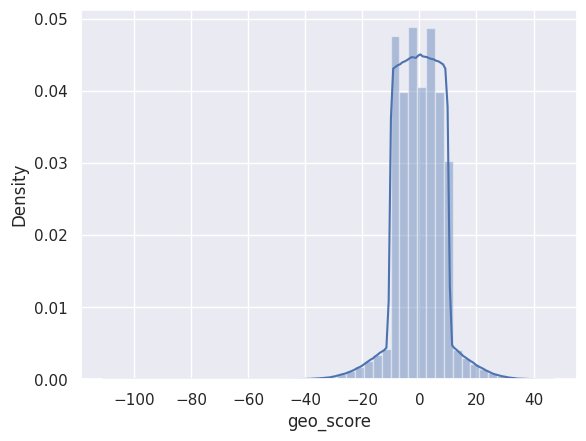

In [24]:
# imputing the missing values

# checking for skewness
sns.distplot(geo['geo_score'])


<Axes: ylabel='geo_score'>

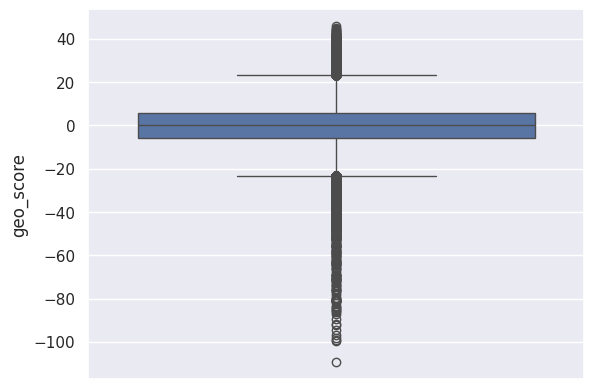

In [25]:
sns.boxplot(geo['geo_score'])

<Axes: xlabel='qsets_normalized_tat', ylabel='Density'>

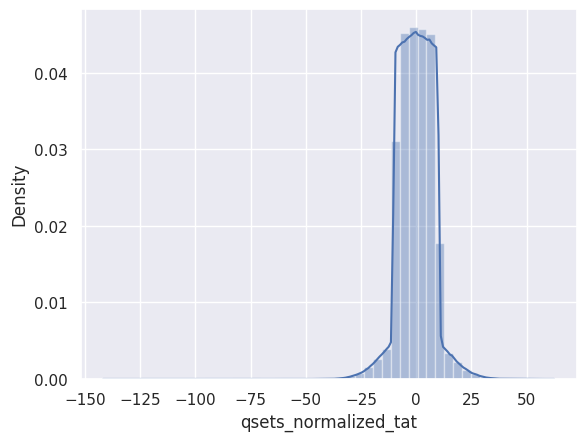

In [21]:
sns.distplot(qset['qsets_normalized_tat'])

<Axes: ylabel='qsets_normalized_tat'>

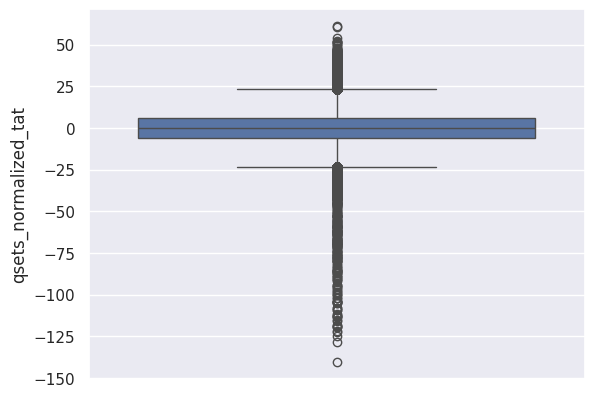

In [26]:
sns.boxplot(qset['qsets_normalized_tat'])

both colms have outliers so filling with median value

In [27]:
geo['geo_score'] = geo['geo_score'].fillna(geo['geo_score'].median())
qset['qsets_normalized_tat'] = qset['qsets_normalized_tat'].fillna(qset['qsets_normalized_tat'].median())

In [28]:
# rechecking for missing values
print('geo:', geo.isnull().sum())
print('qset:', qset.isna().sum())

geo: id           0
geo_score    0
dtype: int64
qset: id                      0
qsets_normalized_tat    0
dtype: int64


In [8]:
# seeing unique values of each colm

print("*******************Unique ID to the customer****************")
print('geo:', geo['id'].nunique())
print('******')
print('instance:', instance['id'].nunique())
print('******')
print('qset:', qset['id'].nunique())
print('******')
print('test:', test['id'].nunique())
print('******')
print('train:', train['id'].nunique())

print("*******************Unique Group to the customer****************")
print('lambda:', lmbda['Group'].nunique())
print('******')
print('test:', test['Group'].nunique())
print('******')
print('train:', train['Group'].nunique())

*******************Unique ID to the customer****************
geo: 284807
******
instance: 284807
******
qset: 284807
******
test: 56962
******
train: 227845
*******************Unique Group to the customer****************
lambda: 1400
******
test: 915
******
train: 1301


here there are max 1424035rows. but these can be multiple transactions by the same id. hence unique values are only 284807

test(56962) + train(227845) = 284807 together will form complete data

 so grouping the transactions by unique id with mean value of all transactions for an id

# merging tables

In [9]:
# to join test & train data we need common colm. we create a new colm 'data' with values as
# "train" for train table and "test" for test table to identify the source after merging

# creating new colms
train['data'] = 'train'
test['data'] = 'test'

In [10]:
train.head(2)

,id,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,...,Dem9,Cred1,Cred2,Cred3,Cred4,Cred5,Cred6,Normalised_FNT,Target,data
0,112751,Grp169,1.070000,0.580000,0.480000,0.766667,1.233333,1.993333,0.34,1.010000,...,0.726667,0.606667,1.01,0.933333,0.603333,0.686667,0.673333,-245.75,0,train
1,18495,Grp161,0.473333,1.206667,0.883333,1.430000,0.726667,0.626667,0.81,0.783333,...,0.743333,0.680000,0.69,0.560000,0.670000,0.553333,0.653333,-248.00,0,train


In [11]:
test.head(2)

,id,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,...,Dem8,Dem9,Cred1,Cred2,Cred3,Cred4,Cred5,Cred6,Normalised_FNT,data
0,146574,Grp229,-0.300000,1.540000,0.22,-0.280000,0.57,0.260000,0.70,1.076667,...,0.546667,0.313333,0.703333,0.813333,0.776667,0.796667,0.823333,0.783333,-249.7500,test
1,268759,Grp141,0.633333,0.953333,0.81,0.466667,0.91,0.253333,1.04,0.550000,...,0.770000,0.993333,0.536667,0.703333,0.806667,0.630000,0.673333,0.673333,-249.8125,test


In [49]:
# adding both tables(train & test) together
all_data = pd.concat([train,test],axis=0)
all_data.shape

(284807, 29)

In [14]:
all_data.tail(10)

,id,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,...,Dem9,Cred1,Cred2,Cred3,Cred4,Cred5,Cred6,Normalised_FNT,Target,data
56952,221425,Grp41,1.313333,0.233333,0.490000,0.346667,0.426667,0.920000,0.236667,0.773333,...,1.166667,0.723333,0.303333,0.520000,0.676667,0.686667,0.650000,-235.2500,NaN,test
56953,57694,Grp86,0.243333,1.136667,1.103333,0.723333,0.556667,0.240000,0.856667,0.713333,...,0.580000,0.706667,0.956667,0.516667,0.356667,0.533333,0.713333,-247.5025,NaN,test
56954,89061,Grp44,-0.013333,0.976667,1.053333,0.310000,0.736667,0.353333,1.060000,-0.430000,...,0.426667,0.730000,0.916667,0.870000,0.970000,0.556667,0.503333,-226.1775,NaN,test
56955,185469,Grp89,0.590000,0.826667,0.700000,0.450000,1.076667,0.760000,0.963333,0.580000,...,0.906667,0.673333,0.686667,0.370000,0.500000,0.616667,0.683333,-244.0825,NaN,test
56956,256138,Grp457,-0.223333,1.543333,0.550000,2.090000,0.436667,0.843333,0.433333,1.236667,...,0.866667,0.546667,0.550000,0.860000,0.893333,0.383333,0.610000,-244.0800,NaN,test
56957,18333,Grp102,0.553333,1.043333,1.096667,0.686667,0.673333,0.340000,0.900000,0.643333,...,0.433333,0.660000,0.776667,0.610000,0.690000,0.750000,0.700000,-249.5050,NaN,test
56958,244207,Grp504,1.353333,0.616667,0.276667,0.783333,0.690000,0.650000,0.473333,0.670000,...,0.870000,0.683333,0.690000,0.640000,0.883333,0.663333,0.660000,-248.7525,NaN,test
56959,103277,Grp78,1.083333,0.433333,0.806667,0.490000,0.243333,0.316667,0.533333,0.606667,...,0.063333,0.753333,0.780000,0.603333,0.880000,0.643333,0.676667,-231.0500,NaN,test
56960,273294,Grp134,0.566667,1.153333,0.370000,0.616667,0.793333,0.226667,0.910000,0.696667,...,1.026667,0.626667,0.646667,0.566667,0.616667,0.713333,0.706667,-246.3150,NaN,test
56961,223337,Grp18,1.426667,0.110000,-0.006667,-0.200000,0.983333,1.870000,0.033333,0.963333,...,0.670000,0.770000,0.893333,0.586667,0.616667,0.683333,0.650000,-248.4500,NaN,test


here target colm value is NAN for test data as its not there in test table

In [16]:
# seeing unique values of each colm again after merging

print("*******************Unique ID to the customer****************")
print('geo:', geo['id'].nunique())
print('******')
print('instance:', instance['id'].nunique())
print('******')
print('qset:', qset['id'].nunique())
print('******')
print('all_data:', all_data['id'].nunique())

print("*******************Unique Group to the customer****************")
print('lambda:', lmbda['Group'].nunique())
print('******')
print('test:', test['Group'].nunique())
print('******')
print('train:', train['Group'].nunique())

*******************Unique ID to the customer****************
geo: 284807
******
instance: 284807
******
qset: 284807
******
all_data: 284807
*******************Unique Group to the customer****************
lambda: 1400
******
test: 915
******
train: 1301


#  grouping the transactions by id where tables having common colm as 'id'

In [18]:
print('geo:', geo.shape,'\n','instance:', instance.shape,'\n','qset:', qset.shape)


geo: (1424035, 2) 
 instance: (1424035, 2) 
 qset: (1424035, 2)


In [20]:
## here we take mean value as from distplot we see the plot is nearly normally distributed,(can also take median)
geo = geo.groupby('id').mean()
instance = instance.groupby('id').mean()
qset = qset.groupby('id').mean()
print('geo:', geo.shape,'\n','instance:', instance.shape,'\n','qset:', qset.shape)

geo: (284807, 1) 
 instance: (284807, 1) 
 qset: (284807, 1)


In [21]:
print('all_data:', all_data.shape,'\n','lmbda:', lmbda.shape)

all_data: (284807, 29) 
 lmbda: (1400, 2)


In [51]:
# merging all_data and lambda tables on 'group' colm
all_data = pd.merge(all_data,lmbda,on='Group',how='left')   #taking left join on all_data to cover maximum data
all_data.shape

(284807, 30)

In [52]:
# merging all_data and geo tables on 'id' colm
all_data = pd.merge(all_data,geo,on='id',how='left')
all_data.shape

(284807, 31)

In [53]:
# merging all_data and instance tables on 'id' colm
all_data = pd.merge(all_data,instance,on='id',how='left')
all_data.shape

(284807, 32)

In [55]:
# merging all_data and qset tables on 'id' colm
all_data = pd.merge(all_data,qset,on='id',how='left')
all_data.shape

(284807, 33)

In [56]:
all_data.head(2)

,id,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,...,Cred4,Cred5,Cred6,Normalised_FNT,Target,data,lambda_wt,geo_score,instance_scores,qsets_normalized_tat
0,112751,Grp169,1.070000,0.580000,0.480000,0.766667,1.233333,1.993333,0.34,1.010000,...,0.603333,0.686667,0.673333,-245.75,0.0,train,-0.13,0.275,-0.06,-0.70
1,18495,Grp161,0.473333,1.206667,0.883333,1.430000,0.726667,0.626667,0.81,0.783333,...,0.670000,0.553333,0.653333,-248.00,0.0,train,0.66,-0.250,0.52,0.14


In [60]:
# after merging on 'group' colm cehcking the unique values
print('all_data:', all_data['Group'].nunique(),'\n','********','\n','lambda:', lmbda['Group'].nunique())

all_data: 1400 
 ******** 
 lambda: 1400


# taking train test data


In [61]:
train = all_data[all_data['data']=='train']
test = all_data[all_data['data']=='test']

In [62]:
print('train:',train.shape,'\n','test:',test.shape)

train: (227845, 33) 
 test: (56962, 33)


In [63]:
# removing unwanted colms

train.columns

Index(['id', 'Group', 'Per1', 'Per2', 'Per3', 'Per4', 'Per5', 'Per6', 'Per7',
       'Per8', 'Per9', 'Dem1', 'Dem2', 'Dem3', 'Dem4', 'Dem5', 'Dem6', 'Dem7',
       'Dem8', 'Dem9', 'Cred1', 'Cred2', 'Cred3', 'Cred4', 'Cred5', 'Cred6',
       'Normalised_FNT', 'Target', 'data', 'lambda_wt', 'geo_score',
       'instance_scores', 'qsets_normalized_tat'],
      dtype='object')

In [64]:
test.columns

Index(['id', 'Group', 'Per1', 'Per2', 'Per3', 'Per4', 'Per5', 'Per6', 'Per7',
       'Per8', 'Per9', 'Dem1', 'Dem2', 'Dem3', 'Dem4', 'Dem5', 'Dem6', 'Dem7',
       'Dem8', 'Dem9', 'Cred1', 'Cred2', 'Cred3', 'Cred4', 'Cred5', 'Cred6',
       'Normalised_FNT', 'Target', 'data', 'lambda_wt', 'geo_score',
       'instance_scores', 'qsets_normalized_tat'],
      dtype='object')

In [65]:
all nan since its not a part of test table/
test['Target']

,Target
227845,NaN
227846,NaN
227847,NaN
227848,NaN
227849,NaN
...,...
284802,NaN
284803,NaN
284804,NaN
284805,NaN


In [66]:
# dropping id,data in train
train.drop(['id','data'],axis=1,inplace=True)

# dropping id,data,target in test
test.drop(['id','data','Target'],axis=1,inplace=True)

In [69]:
# checking null values
print('train:',train.isna().sum().sum())   # seeing total null
print('test:', test.isna().sum().sum())

train: 0
test: 0


here 'Group' is an object colm so has to be encoded to numeric while model building

In [67]:
unseen_test_data = test.copy()

**changing categorical 'Group' colm into numerical**

In [72]:
unseen_test_data['Group'] = unseen_test_data['Group'].astype('category')
unseen_test_data['Group'] = unseen_test_data['Group'].cat.codes
unseen_test_data['Group']

,Group
227845,277
227846,180
227847,231
227848,485
227849,504
...,...
284802,11
284803,569
284804,765
284805,163


#train test splitting

In [81]:
x= train.drop(['Target'],axis=1)
y = train['Target']

In [82]:
y.value_counts(normalize=True)

,proportion
Target,
0.0,0.998271
1.0,0.001729


there's class imbalance so we use stratify

In [83]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=101,stratify=y)

# # Building Model

In [76]:
# rainforest model

from sklearn.ensemble import RandomForestClassifier
rfm = RandomForestClassifier()
rfm.fit(x_train,y_train)

ValueError: could not convert string to float: 'Grp16'

In [77]:
x.columns

Index(['Group', 'Per1', 'Per2', 'Per3', 'Per4', 'Per5', 'Per6', 'Per7', 'Per8',
       'Per9', 'Dem1', 'Dem2', 'Dem3', 'Dem4', 'Dem5', 'Dem6', 'Dem7', 'Dem8',
       'Dem9', 'Cred1', 'Cred2', 'Cred3', 'Cred4', 'Cred5', 'Cred6',
       'Normalised_FNT', 'lambda_wt', 'geo_score', 'instance_scores',
       'qsets_normalized_tat'],
      dtype='object')

In [80]:
# changing train[Group] into numerical
train['Group'] = train['Group'].astype('category')
train['Group'] = train['Group'].cat.codes

In [84]:
# rainforest model

from sklearn.ensemble import RandomForestClassifier
rfm = RandomForestClassifier()
rfm.fit(x_train,y_train)

RandomForestClassifier()

In [85]:
y_pred_train = rfm.predict(x_train)
y_pred_test = rfm.predict(x_test)

# evaluation of model

In [86]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

print('classification report of train data','\n')
print(classification_report(y_train,y_pred_train))
print()
print('classification report of test data','\n')
print(classification_report(y_test,y_pred_test))

classification report of train data 

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    181961
         1.0       1.00      1.00      1.00       315

    accuracy                           1.00    182276
   macro avg       1.00      1.00      1.00    182276
weighted avg       1.00      1.00      1.00    182276


classification report of test data 

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     45490
         1.0       0.95      0.70      0.80        79

    accuracy                           1.00     45569
   macro avg       0.97      0.85      0.90     45569
weighted avg       1.00      1.00      1.00     45569



In [87]:
# checking for overfitting
print('accuracy_score of train data:', accuracy_score(y_train,y_pred_train))
print('accuracy_score of test data:', accuracy_score(y_test,y_pred_test))

accuracy_score of train data: 0.9999945138142158
accuracy_score of test data: 0.9994074919353069


# prediction

In [88]:
final_op = rfm.predict(unseen_test_data)
final_op

array([0., 0., 0., ..., 0., 0., 0.])

In [90]:
final_op = pd.DataFrame(final_op,columns = ['prediction'])
final_op

,prediction
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
56957,0.0
56958,0.0
56959,0.0
56960,0.0


In [91]:
final_op = pd.concat([unseen_test_data,final_op],axis=1)
final_op

,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,Per9,...,Cred3,Cred4,Cred5,Cred6,Normalised_FNT,lambda_wt,geo_score,instance_scores,qsets_normalized_tat,prediction
227845,277.0,-0.300000,1.540000,0.220000,-0.280000,0.570000,0.260000,0.700000,1.076667,0.930000,...,0.776667,0.796667,0.823333,0.783333,-249.7500,0.76,0.25,-0.04,-0.5375,NaN
227846,180.0,0.633333,0.953333,0.810000,0.466667,0.910000,0.253333,1.040000,0.550000,0.543333,...,0.806667,0.630000,0.673333,0.673333,-249.8125,0.18,0.43,-0.77,-0.6200,NaN
227847,231.0,1.043333,0.740000,0.860000,1.006667,0.583333,0.616667,0.630000,0.686667,0.593333,...,0.870000,0.596667,0.680000,0.670000,-248.1200,0.39,1.32,0.11,-0.5125,NaN
227848,485.0,1.283333,0.300000,0.576667,0.636667,0.256667,0.543333,0.356667,0.663333,1.156667,...,0.456667,0.320000,0.676667,0.660000,-222.9875,1.80,-2.11,0.33,0.4625,NaN
227849,504.0,1.186667,0.326667,0.476667,0.866667,0.436667,0.680000,0.476667,0.686667,1.476667,...,0.566667,0.546667,0.650000,0.663333,-196.2200,1.89,-2.11,-0.37,-0.1300,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56957,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
56958,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
56959,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
56960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [94]:
# no. of potential fraud transactions
final_op['prediction'].value_counts()

,count
prediction,
0.0,56882
1.0,80


In [95]:
final_op.to_csv('finance_fraud_detection.csv')